### CRAG

传统RAG为检索->生成.如果检索到的文档不相关,则模型会基于错误信息胡说八道  
CRAG在RAG的流程中引入了自我反思与纠错

#### 一,CRAG


CRAG 是一种主动检索（Active RAG）或自省式 RAG（Self-reflective RAG）的方法。它的核心思想是在检索之后、生成之前，增加一个“评分（Grading）”环节，用来评估检索到的文档与用户问题之间的相关性.  

如果检索结果不好，系统不会盲目生成，而是会触发一个“纠正”动作(例如通过网络搜索来补充知识)

#### 二,核心流程  
1. 检索（Retrieve）：首先从向量数据库中检索相关的文档片段
2. 评分（Grade）：使用一个“评分器”（通常是一个轻量级的 LLM）对每个检索到的文档进行评估，判断其是否与问题相关
3. 决策（Decision）：
    ◦ 完全相关：如果文档质量很高，直接进入生成步骤
    ◦ 不相关/不确定：如果文档不相关，或者模型认为现有的知识不足以回答问题，系统会认为这超出了本地知识库的范畴
4. 纠正（Correct/Fallback）：当本地检索失败时，CRAG 会触发网络搜索（Web Search），并将搜索结果作为补充上下文
5. 查询重写（Query Transformation）：在进行网络搜索前，通常会利用 LLM 对原始问题进行改写，以优化搜索效果
6. 生成（Generate）：最后，LLM 结合经过筛选的本地文档和（如果有的话）网络搜索到的新信息，生成最终答案

#### 三,LangGraph实现
CRAG 实际上是一个状态机（State Machine）。它包含多个节点（Node）和条件边（Conditional Edges）：  

• 节点：执行具体的任务，如检索、评分、重写查询、网页搜索、生成  

• 状态（State）：一个在图节点间传递的字典，包含问题、文档、生成的内容等信息  

• 流程工程：通过 LangGraph，你可以清晰地定义：如果评分结果是“no”，下一步必须跳转到“web_search”节点

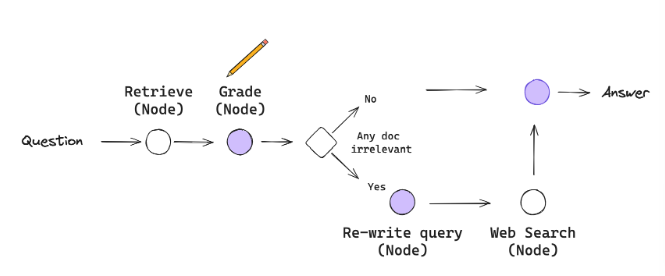

In [1]:
import os
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = CharacterTextSplitter(chunk_size=250, chunk_overlap=0)
doc_splits = text_splitter.split_documents(docs_list)

EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embeddings,
)
retriever = vectorstore.as_retriever()

c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.
Created a chunk of size 491, which is longer than the specified 250
Created a chunk of size 341, which is longer than the specified 250
Created a chunk of size 336, which is longer than the specified 250
Created a chunk of size 252, which is longer than the specified 250
Created a chunk of size 2671, which is longer than the specified 250
Created a chunk of size 716, which is longer than the specified 250
Created a chunk of size 620, which is longer than the specified 250
Created a chunk of size 1373, which is longer than the specified 250
Created a chunk of size 738, which is longer than the specified 250
Created a chunk of size 1281, which i

In [2]:
### Retrieval Grader
from langchain_community.chat_models.tongyi import ChatTongyi  # 通义千问
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

# 通义千问配置（使用你提供的API Key和模型）
LLM_MODEL = "qwen-turbo"  # 通义千问免费模型
TEMPERATURE = 0.0  # 生成温度（0=稳定输出）
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY

# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )
llm = ChatTongyi(
  model = LLM_MODEL,
  temperature = TEMPERATURE,
)


# LLM with function call
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader
question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


In [3]:
### Generate

from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = hub.pull("rlm/rag-prompt")


# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

Agent memory in LLM-powered autonomous systems includes short-term memory for in-context learning and long-term memory using external vector stores for extended information retention and retrieval. This allows the agent to manage complex tasks by breaking them into subgoals and refining actions through reflection. The memory components work alongside planning and tool use to enhance the agent's problem-solving capabilities.


In [4]:

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'What is agent memory and how does it work in artificial intelligence systems?'

In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(
    k=3,
    tavily_api_key="tvly-4GzKsV-fAi55mwbNQwT7JG9JcezoPiM33oWLoxBwtRQHhoVnx"  # 注意去掉 'dev' 部分
)

C:\Users\23017\AppData\Local\Temp\ipykernel_15716\2991536031.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(


#### Creat Graph

In [6]:
### Define
from typing import List

from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

In [7]:
from langchain_core.documents import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

 
    documents = retriever.invoke(question)  
    return {"documents": documents, "question": question}

def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    web_search = "No"
    
    for i, d in enumerate(documents):
        print(f"--- Grading document {i+1}/{len(documents)} ---")
        try:
            score = retrieval_grader.invoke(
                {"question": question, "document": d.page_content}
            )
            print(f"DEBUG: score = {score}, type = {type(score)}")
            
            # 处理可能的 None 返回值
            if score is None:
                print("---GRADE: LLM RETURNED NONE, TREATING AS NOT RELEVANT---")
                grade = "no"
            else:
                grade = score.binary_score  # 如果 score 有 binary_score 属性
        except Exception as e:
            print(f"---GRADE: ERROR DURING GRADING: {e}---")
            grade = "no"  # 出错时默认不相关
        
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            # 注意：continue 会跳过后续文档，但这里不需要 continue，因为我们要遍历所有文档
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    # 执行搜索
    docs = web_search_tool.invoke({"query": question})

   
    print("DEBUG: docs =", docs)
    print("DEBUG: type of first element =", type(docs[0]) if docs else "empty")

    # 智能提取文本
    web_results_lines = []
    for d in docs:
        if isinstance(d, dict):
            # 尝试常见字段
            content = d.get("content") or d.get("snippet") or d.get("text") or str(d)
        else:
            content = str(d)   # 如果是字符串，直接转换
        web_results_lines.append(content)

    web_results = "\n".join(web_results_lines)
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}

### Edges


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [8]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

In [9]:
from pprint import pprint

# Run
inputs = {"question": "What are the types of agent memory?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
--- Grading document 1/4 ---
DEBUG: score = binary_score='yes', type = <class '__main__.GradeDocuments'>
---GRADE: DOCUMENT RELEVANT---
--- Grading document 2/4 ---
DEBUG: score = binary_score='no', type = <class '__main__.GradeDocuments'>
---GRADE: DOCUMENT NOT RELEVANT---
--- Grading document 3/4 ---
DEBUG: score = binary_score='yes', type = <class '__main__.GradeDocuments'>
---GRADE: DOCUMENT RELEVANT---
--- Grading document 4/4 ---
DEBUG: score = binary_score='no', type = <class '__main__.GradeDocuments'>
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
"Node 'grade_documents':"
'\n---\n'
---TRANSFORM QUERY---
"Node 'transform_query':"
'\n---\n'
---WEB SEARCH---
DEBUG: docs = HTTPError('401 Client Error: Unauthorized for url: https://api.tavily.com/search')
DEBUG: type of first element = <class 'str'>
"Nod

In [10]:
from pprint import pprint

# Run
inputs = {"question": "How does the AlphaCodium paper work?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
--- Grading document 1/4 ---
DEBUG: score = None, type = <class 'NoneType'>
---GRADE: LLM RETURNED NONE, TREATING AS NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
--- Grading document 2/4 ---
DEBUG: score = None, type = <class 'NoneType'>
---GRADE: LLM RETURNED NONE, TREATING AS NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
--- Grading document 3/4 ---
DEBUG: score = None, type = <class 'NoneType'>
---GRADE: LLM RETURNED NONE, TREATING AS NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
--- Grading document 4/4 ---
DEBUG: score = binary_score='no', type = <class '__main__.GradeDocuments'>
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
"Node 'grade_documents':"
'\n---\n'
---TRANSFORM QUERY---
"Node 'transform_query':"
'\n---\n'
---WEB SEARCH---
DEBUG: docs = HTTPError('401 Client Error: Unauthoriz

### tavily需要付费,所以这里没有输出检索答案

In [14]:
from langchain_community.tools import DuckDuckGoSearchRun  # 替换 TavilySearchResults
web_search_tool = DuckDuckGoSearchRun()

In [15]:
from langchain_core.documents import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

 
    documents = retriever.invoke(question)  
    return {"documents": documents, "question": question}

def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    web_search = "No"
    
    for i, d in enumerate(documents):
        print(f"--- Grading document {i+1}/{len(documents)} ---")
        try:
            score = retrieval_grader.invoke(
                {"question": question, "document": d.page_content}
            )
            print(f"DEBUG: score = {score}, type = {type(score)}")
            
            # 处理可能的 None 返回值
            if score is None:
                print("---GRADE: LLM RETURNED NONE, TREATING AS NOT RELEVANT---")
                grade = "no"
            else:
                grade = score.binary_score  # 如果 score 有 binary_score 属性
        except Exception as e:
            print(f"---GRADE: ERROR DURING GRADING: {e}---")
            grade = "no"  # 出错时默认不相关
        
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            # 注意：continue 会跳过后续文档，但这里不需要 continue，因为我们要遍历所有文档
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    try:
        result = web_search_tool.invoke({"query": question})
        print(f"DEBUG: DuckDuckGo result type = {type(result)}")
    except Exception as e:
        print(f"Web search failed: {e}")
        result = ""  # 失败时设为空字符串

    # 将结果转换为统一的文档列表格式
    # 如果结果是字符串，转换为单元素列表；如果已经是列表，保留
    if isinstance(result, str):
        docs = [result]
    elif isinstance(result, list):
        docs = result
    else:
        docs = [str(result)]  # 兜底转换

    # 智能提取文本（兼容字典或字符串）
    web_results_lines = []
    for d in docs:
        if isinstance(d, dict):
            # 尝试常见字段（DuckDuckGo 返回字典时可能有 'snippet'）
            content = d.get("snippet") or d.get("content") or d.get("text") or str(d)
        else:
            content = str(d)
        web_results_lines.append(content)

    web_results = "\n".join(web_results_lines)
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}

### Edges


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [16]:
from pprint import pprint

# Run
inputs = {"question": "What are the types of agent memory?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
--- Grading document 1/4 ---
DEBUG: score = binary_score='yes', type = <class '__main__.GradeDocuments'>
---GRADE: DOCUMENT RELEVANT---
--- Grading document 2/4 ---
DEBUG: score = binary_score='no', type = <class '__main__.GradeDocuments'>
---GRADE: DOCUMENT NOT RELEVANT---
--- Grading document 3/4 ---
DEBUG: score = binary_score='yes', type = <class '__main__.GradeDocuments'>
---GRADE: DOCUMENT RELEVANT---
--- Grading document 4/4 ---
DEBUG: score = None, type = <class 'NoneType'>
---GRADE: LLM RETURNED NONE, TREATING AS NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
"Node 'grade_documents':"
'\n---\n'
---TRANSFORM QUERY---
"Node 'transform_query':"
'\n---\n'
---WEB SEARCH---


Impersonate 'chrome_104' does not exist, using 'random'


DEBUG: docs = Building Applications with AI Agents Designing and Implementing Multiagent Systems Michael Albada “ The best single-volume introduction to building AI agent systems—you can read hundreds of papers or this one book.” Arun Rao Ex-Meta GenAI group, adjunct professor at UCLA Building Applications with AI Agents Generative AI has revolutionized how organizations tackle problems, accelerating ... What this book covers Chapter 1, From Prompts to Context : Building the Semantic Blueprint, introduces the principles of context engineering and demonstrates how structured context , semantic blueprints, and agent orchestration transform generative AI from prompt-based unpredictability into reliable, goaldriven systems. The Guide Answers the Heritage of World Civilizations Every now and then, a topic captures peopleâ€TMs attention in unexpected ways. The heritage of world civilizations is one such subject that intricately weaves the narrative of humanity's journey across time and space

In [17]:
from pprint import pprint

# Run
inputs = {"question": "How does the AlphaCodium paper work?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
--- Grading document 1/4 ---
DEBUG: score = None, type = <class 'NoneType'>
---GRADE: LLM RETURNED NONE, TREATING AS NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
--- Grading document 2/4 ---
DEBUG: score = None, type = <class 'NoneType'>
---GRADE: LLM RETURNED NONE, TREATING AS NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
--- Grading document 3/4 ---
DEBUG: score = None, type = <class 'NoneType'>
---GRADE: LLM RETURNED NONE, TREATING AS NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
--- Grading document 4/4 ---
DEBUG: score = None, type = <class 'NoneType'>
---GRADE: LLM RETURNED NONE, TREATING AS NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
"Node 'grade_documents':"
'\n---\n'
---TRANSFORM QUERY---
"Node 'transform_query':"
'\n---\n'
---WEB SEARCH---
DEBUG: docs = Jan 16, 20